In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Makes plots look nice
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style("whitegrid")

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
matches = pd.read_csv('../data/raw/matches.csv')
deliveries = pd.read_csv('../data/raw/deliveries.csv')

print("Matches shape:", matches.shape)
print("Deliveries shape:", deliveries.shape)

Matches shape: (1095, 20)
Deliveries shape: (260920, 17)


In [3]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [4]:
print("Matches columns:", matches.columns.tolist())
print("\nDeliveries columns:", deliveries.columns.tolist())

Matches columns: ['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']

Deliveries columns: ['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']


In [5]:
print("=== Missing values in matches ===")
print(matches.isnull().sum())

=== Missing values in matches ===
id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64


In [6]:
print("\n=== Missing values in deliveries ===")
print(deliveries.isnull().sum())


=== Missing values in deliveries ===
match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64


In [7]:
print("Seasons covered:", sorted(matches['season'].unique()))
print("\nTotal teams:", matches['team1'].nunique())
print("Teams:", sorted(matches['team1'].unique()))

Seasons covered: ['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022', '2023', '2024']

Total teams: 19
Teams: ['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Delhi Daredevils', 'Gujarat Lions', 'Gujarat Titans', 'Kings XI Punjab', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiant', 'Rising Pune Supergiants', 'Royal Challengers Bangalore', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']


In [8]:
print("Sample winners:\n", matches['winner'].value_counts().head(10))
print("\nNull winners (no result/abandoned):", matches['winner'].isnull().sum())

Sample winners:
 winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Sunrisers Hyderabad             88
Kings XI Punjab                 88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Name: count, dtype: int64

Null winners (no result/abandoned): 5


In [9]:
print(matches[['toss_winner', 'toss_decision', 'winner']].head(10))

                   toss_winner toss_decision                       winner
0  Royal Challengers Bangalore         field        Kolkata Knight Riders
1          Chennai Super Kings           bat          Chennai Super Kings
2             Rajasthan Royals           bat             Delhi Daredevils
3               Mumbai Indians           bat  Royal Challengers Bangalore
4              Deccan Chargers           bat        Kolkata Knight Riders
5              Kings XI Punjab           bat             Rajasthan Royals
6              Deccan Chargers           bat             Delhi Daredevils
7               Mumbai Indians         field          Chennai Super Kings
8             Rajasthan Royals         field             Rajasthan Royals
9               Mumbai Indians         field              Kings XI Punjab


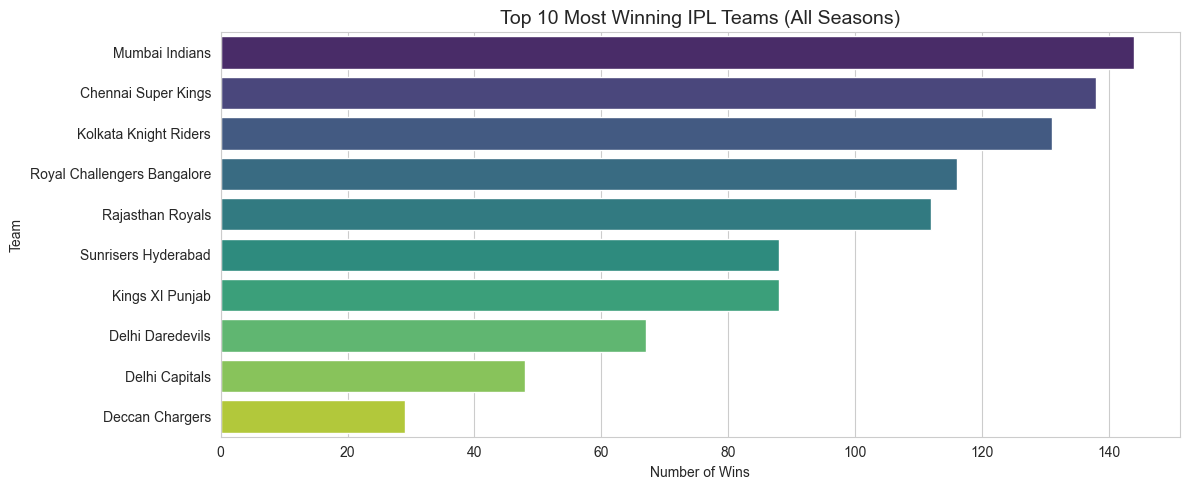

Chart saved!


In [11]:
top_winners = matches['winner'].value_counts().head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=top_winners.values, y=top_winners.index, 
            hue=top_winners.index, palette='viridis', legend=False)
plt.title('Top 10 Most Winning IPL Teams (All Seasons)', fontsize=14)
plt.xlabel('Number of Wins')
plt.ylabel('Team')
plt.tight_layout()
plt.savefig('../reports/visualizations/top_winners.png', dpi=150)
plt.show()
print("Chart saved!")

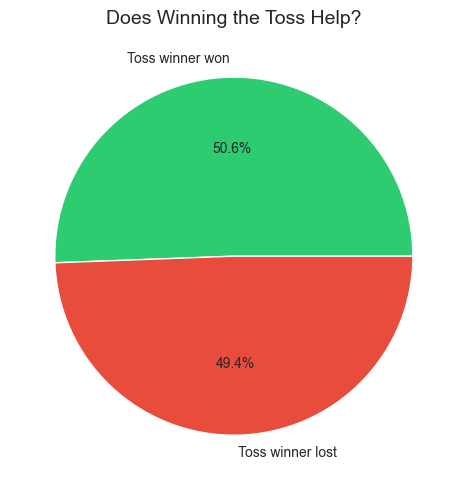

In [12]:
matches['toss_match_winner'] = matches['toss_winner'] == matches['winner']
toss_impact = matches['toss_match_winner'].value_counts()

plt.figure(figsize=(6, 5))
plt.pie(toss_impact.values, 
        labels=['Toss winner won', 'Toss winner lost'], 
        autopct='%1.1f%%', 
        colors=['#2ecc71', '#e74c3c'])
plt.title('Does Winning the Toss Help?', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/visualizations/toss_impact.png', dpi=150)
plt.show()

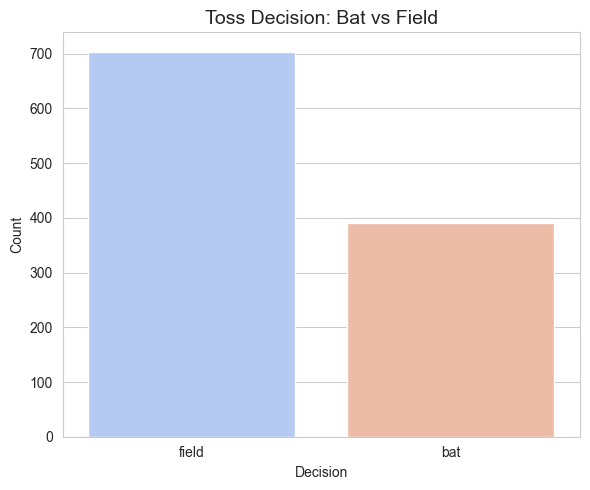

In [13]:
toss_decision = matches['toss_decision'].value_counts()

plt.figure(figsize=(6, 5))
sns.barplot(x=toss_decision.index, y=toss_decision.values, 
            hue=toss_decision.index, palette='coolwarm', legend=False)
plt.title('Toss Decision: Bat vs Field', fontsize=14)
plt.xlabel('Decision')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../reports/visualizations/toss_decision.png', dpi=150)
plt.show()

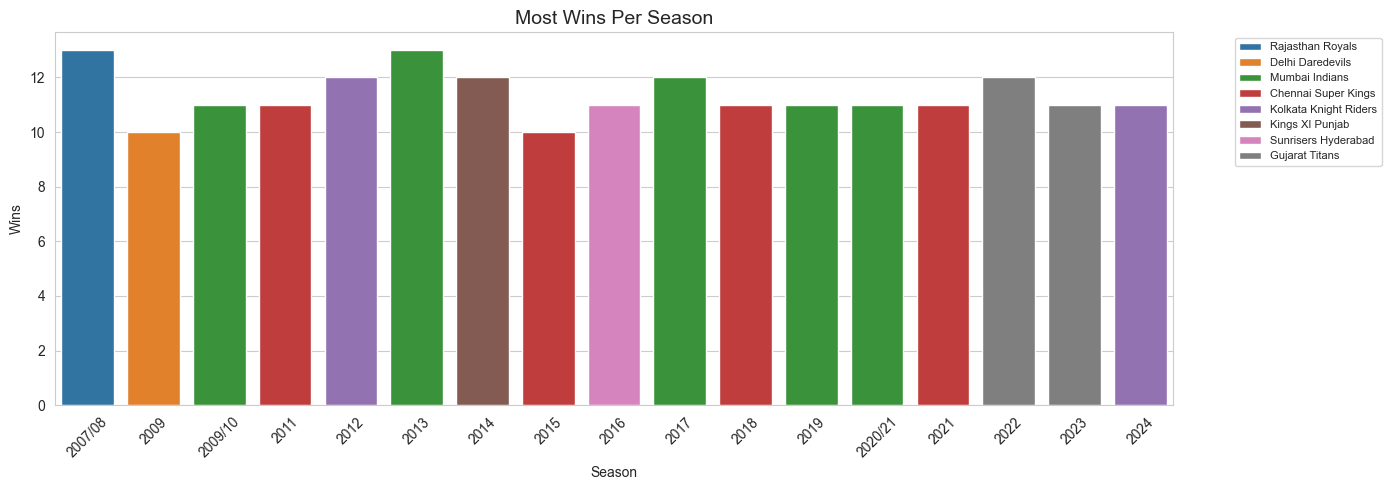

In [14]:
season_wins = matches.groupby(['season', 'winner']).size().reset_index(name='wins')
top_per_season = season_wins.sort_values('wins', ascending=False).groupby('season').first().reset_index()

plt.figure(figsize=(14, 5))
sns.barplot(data=top_per_season, x='season', y='wins', hue='winner')
plt.title('Most Wins Per Season', fontsize=14)
plt.xlabel('Season')
plt.ylabel('Wins')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('../reports/visualizations/wins_per_season.png', dpi=150)
plt.show()